In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

In [27]:
df1 = pd.read_csv("yere1.csv")
df2 = pd.read_csv("yere2.csv")

df = pd.concat([df1, df2], ignore_index=True)

In [28]:
df.shape

(1967, 33)

In [29]:
m = df.isnull().sum()
p = m/len(df)*100
p

name                  0.000000
datetime              0.000000
tempmax               0.000000
tempmin               0.000000
temp                  0.000000
feelslikemax          0.000000
feelslikemin          0.000000
feelslike             0.000000
dew                   0.000000
humidity              0.000000
precip                0.000000
precipprob            0.000000
precipcover           0.000000
preciptype           65.022877
snow                  0.000000
snowdepth             0.000000
windgust              0.000000
windspeed             0.000000
winddir               0.000000
sealevelpressure      0.000000
cloudcover            0.000000
visibility            0.000000
solarradiation        0.000000
solarenergy           0.000000
uvindex               0.000000
severerisk          100.000000
sunrise               0.000000
sunset                0.000000
moonphase             0.000000
conditions            0.000000
description           0.000000
icon                  0.000000
stations

In [30]:
df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Yerevan,2017-11-01,14.9,7.9,10.5,14.9,7.9,10.5,6.8,80.2,...,11.1,5,NaN,2017-11-01T07:31:11,2017-11-01T17:59:15,0.41,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"37871099999,37717099999,37785099999,1710009999..."
1,Yerevan,2017-11-02,13.9,2.2,7.4,13.9,-0.2,6.9,-1.2,59.5,...,13.6,6,NaN,2017-11-02T07:32:20,2017-11-02T17:58:04,0.44,Clear,Clear conditions throughout the day.,clear-day,"37871099999,37717099999,37785099999,1710009999..."
2,Yerevan,2017-11-03,14.9,-1.0,6.6,14.9,-1.0,6.4,-1.1,61.8,...,13.5,6,NaN,2017-11-03T07:33:29,2017-11-03T17:56:55,0.47,Clear,Clear conditions throughout the day.,clear-day,"37871099999,37717099999,37785099999,1710009999..."
3,Yerevan,2017-11-04,15.9,1.5,8.4,15.9,1.5,8.4,2.1,68.4,...,12.6,6,NaN,2017-11-04T07:34:39,2017-11-04T17:55:47,0.50,Clear,Clear conditions throughout the day.,clear-day,"37871099999,37717099999,37785099999,1710009999..."
4,Yerevan,2017-11-05,17.7,2.4,9.5,17.7,2.4,9.5,3.5,68.7,...,12.1,6,NaN,2017-11-05T07:35:48,2017-11-05T17:54:41,0.54,Clear,Clear conditions throughout the day.,clear-day,"37871099999,37717099999,37785099999,1710009999..."


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1967 non-null   object 
 1   datetime          1967 non-null   object 
 2   tempmax           1967 non-null   float64
 3   tempmin           1967 non-null   float64
 4   temp              1967 non-null   float64
 5   feelslikemax      1967 non-null   float64
 6   feelslikemin      1967 non-null   float64
 7   feelslike         1967 non-null   float64
 8   dew               1967 non-null   float64
 9   humidity          1967 non-null   float64
 10  precip            1967 non-null   float64
 11  precipprob        1967 non-null   int64  
 12  precipcover       1967 non-null   float64
 13  preciptype        688 non-null    object 
 14  snow              1967 non-null   float64
 15  snowdepth         1967 non-null   float64
 16  windgust          1967 non-null   float64


In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [33]:
df.severerisk.isna().sum()

1967

In [8]:
df.columns

Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')

In [9]:
df.set_index('datetime', inplace=True)

In [10]:
df.columns

Index(['name', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
       'preciptype', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset',
       'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')

In [ ]:
# Resample the data to weekly means
weekly_means = df.resample('W').mean(numeric_only=True)
df = weekly_means

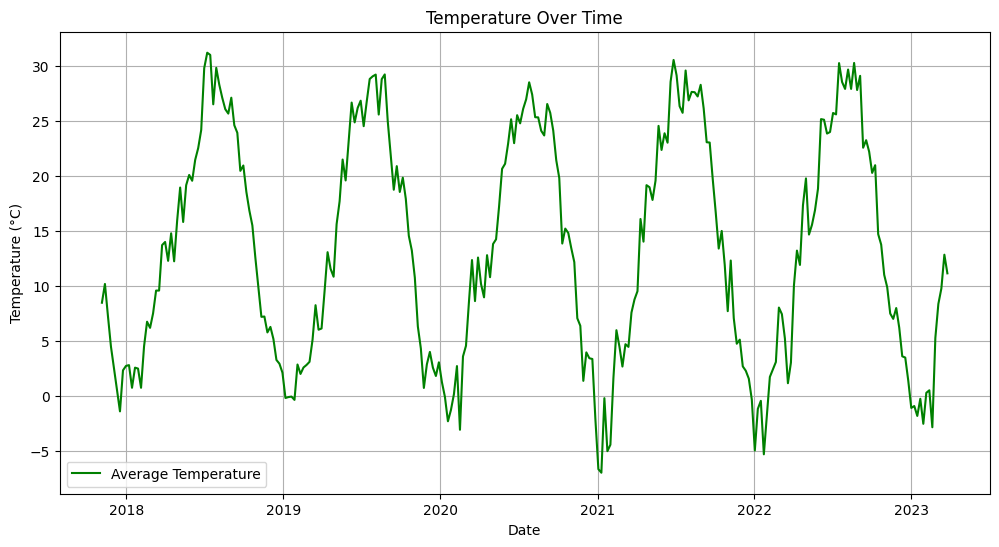

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['temp'], label='Average Temperature', color='green')
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()

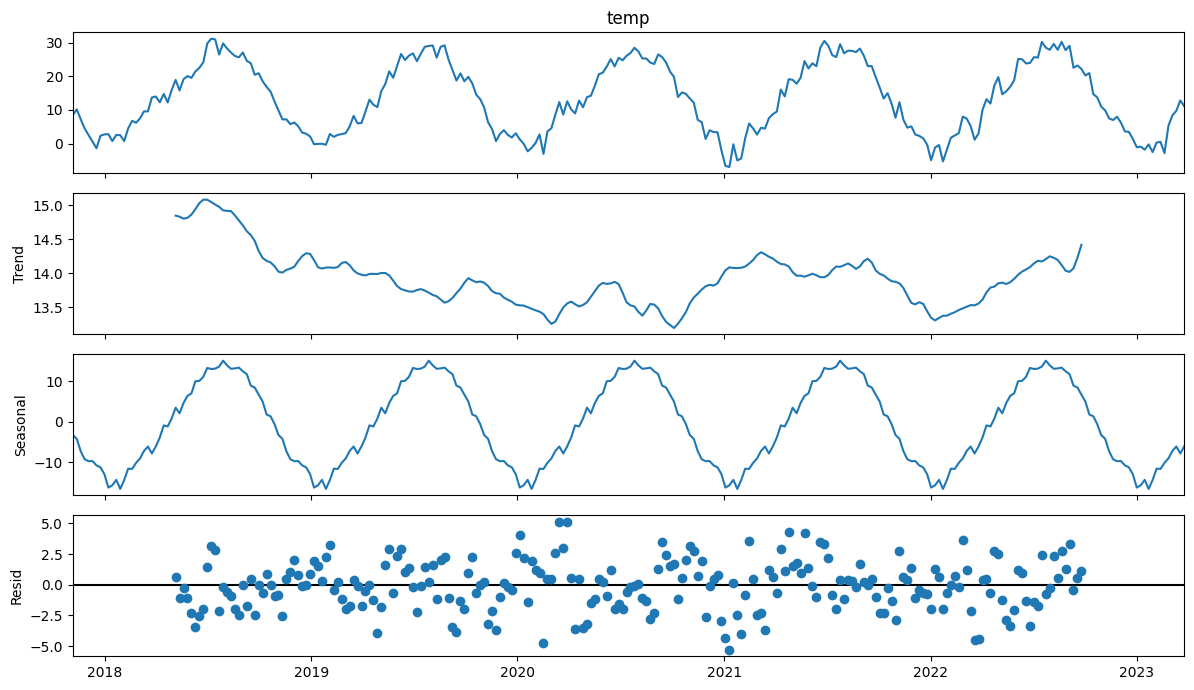

In [13]:
model_add = seasonal_decompose(df['temp'], model='additive',period = 52)
fig = model_add.plot()
fig.set_size_inches((12, 7))
fig.tight_layout()
plt.show()

In [ ]:
df.drop(["tempmax", "tempmin", "feelslikemax", "snow", "feelslikemin", "severerisk", "feelslike", "solarenergy", "snowdepth", "windgust", "moonphase", "preciptype"], axis=1, inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns

<Axes: >

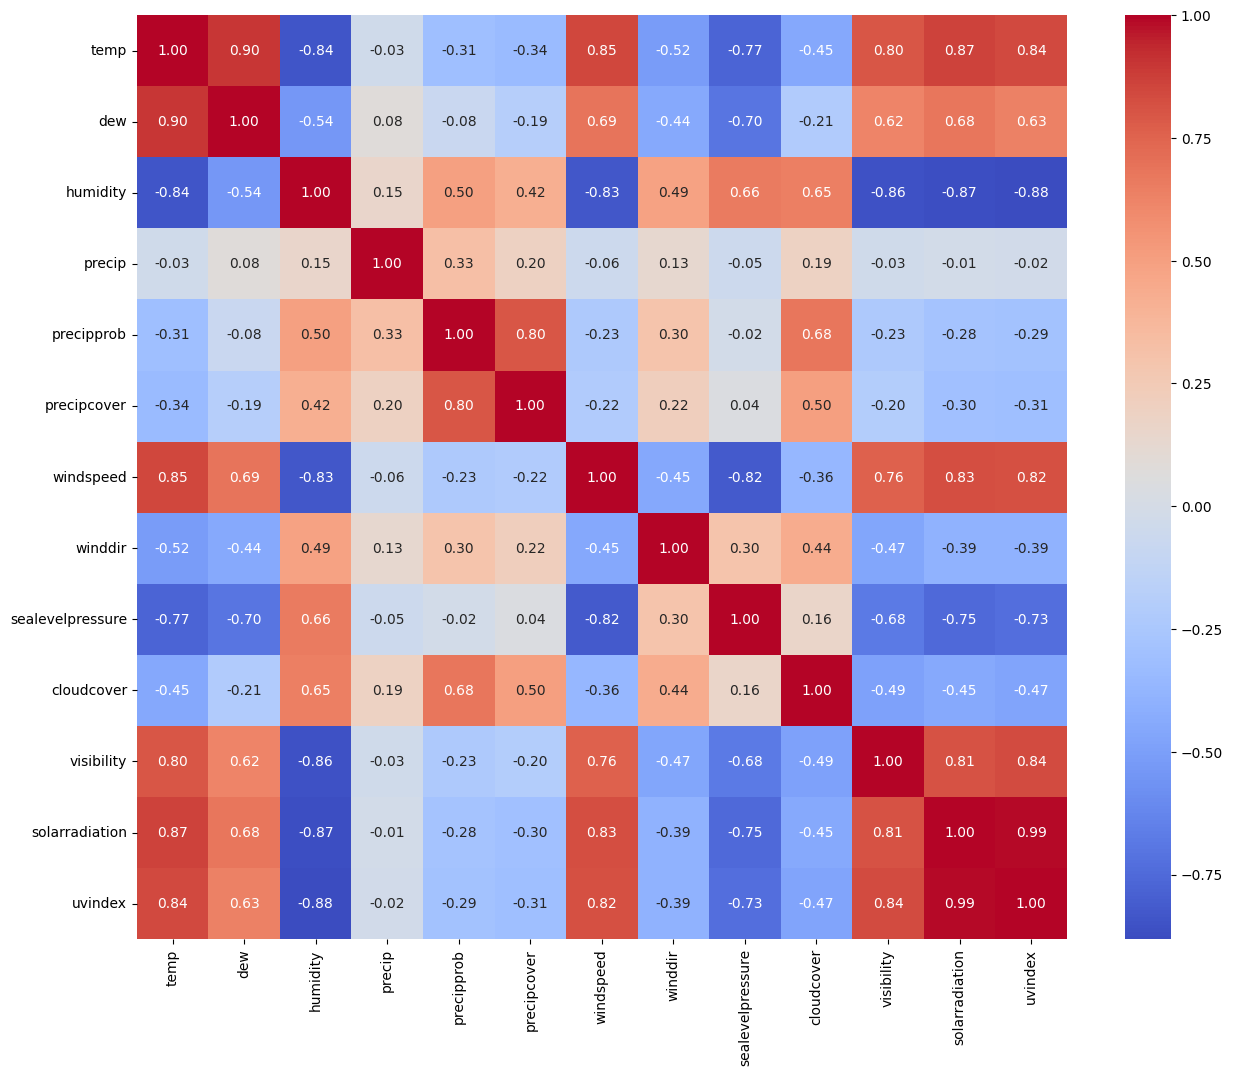

In [18]:
n = df.select_dtypes(include=np.number)
plt.figure(figsize=(15, 12))
correlation_matrix = n.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

C:\Users\manem\AppData\Local\Temp\ipykernel_8700\3491559288.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df['temp'].resample('M').mean()


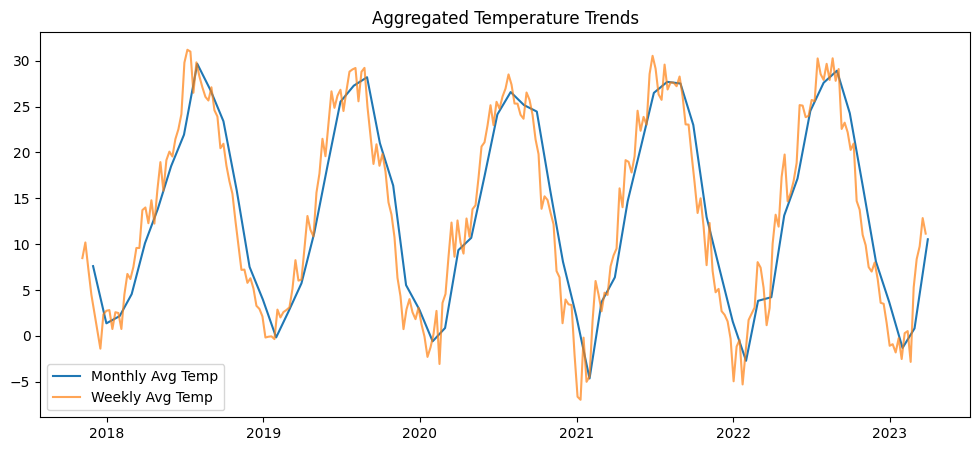

In [ ]:
df_monthly = df['temp'].resample('M').mean()
df_weekly = df['temp'].resample('W').mean()

plt.figure(figsize=(12,5))
plt.plot(df_monthly, label='Monthly Avg Temp')
plt.plot(df_weekly, label='Weekly Avg Temp', alpha=0.7)
plt.title('Aggregated Temperature Trends')
plt.legend()
plt.show()

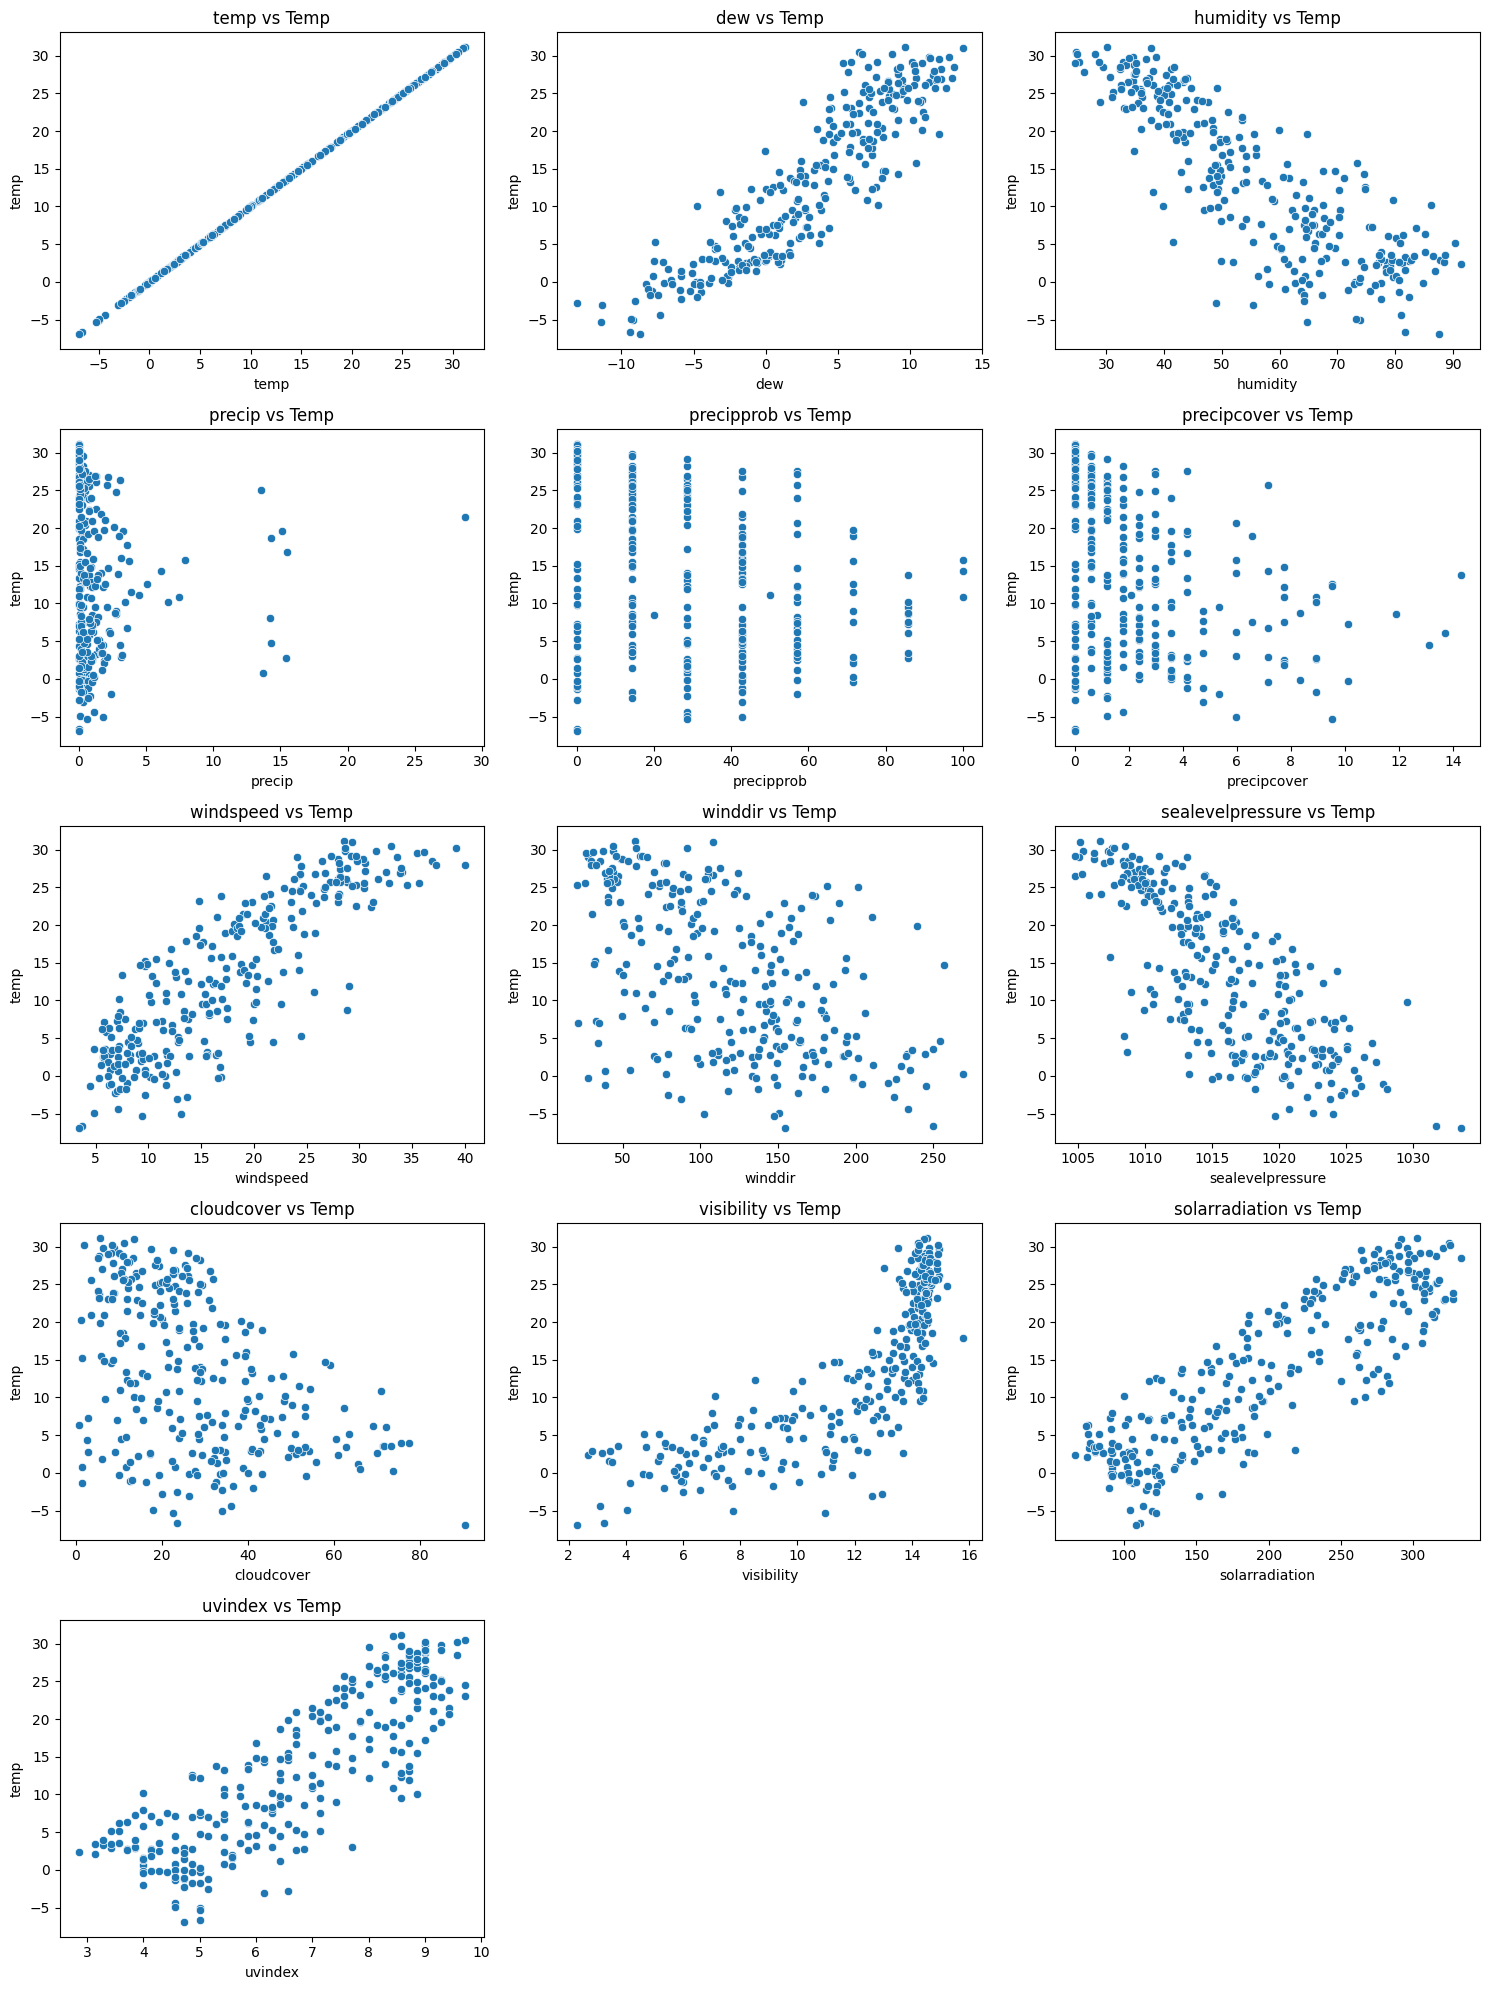

In [20]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(x=df[col], y=df['temp'], ax=axes[i])
    axes[i].set_title(f'{col} vs Temp')

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
# ADF Test

ts = df.sort_values("datetime")["temp"].dropna()

adf_result = adfuller(df['temp'])
print("ADF Test Results:")
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print(f'Critical Values: {adf_result[4]}')

# KPSS Test
kpss_result = kpss(df['temp'], regression='c')
print("\nKPSS Test Results:")
print(f'KPSS Statistic: {kpss_result[0]}')
print(f'p-value: {kpss_result[1]}')
print(f'Critical Values: {kpss_result[3]}')

if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
    print('The time series data is stationary based on ADF and KPSS tests.')
elif adf_result[1] >= 0.05 and kpss_result[1] < 0.05:
    print('The time series data is non-stationary based on both ADF and KPSS tests.')
elif adf_result[1] >= 0.05 and kpss_result[1] >= 0.05:
    print('The time series data is non-stationary based on ADF test, but stationary based on KPSS test.')
else:
    print('The time series data is inconclusive for stationarity based on ADF and KPSS tests.')

ADF Test Results:
ADF Statistic: -8.70579290907422
p-value: 3.7034424576569266e-14
Critical Values: {'1%': -3.4552699038400827, '5%': -2.8725092359464526, '10%': -2.5726152830188678}

KPSS Test Results:
KPSS Statistic: 0.035419378291501456
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
The time series data is stationary based on ADF and KPSS tests.


C:\Users\manem\AppData\Local\Temp\ipykernel_8700\742344421.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df['temp'], regression='c')


In [22]:
df.reset_index(inplace = True)

<Figure size 1200x600 with 0 Axes>

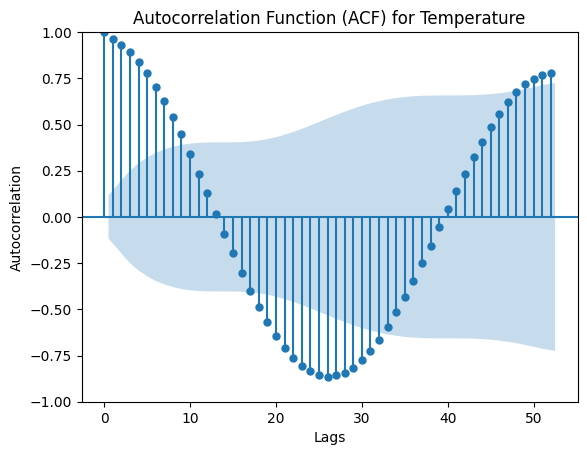

<Figure size 1200x600 with 0 Axes>

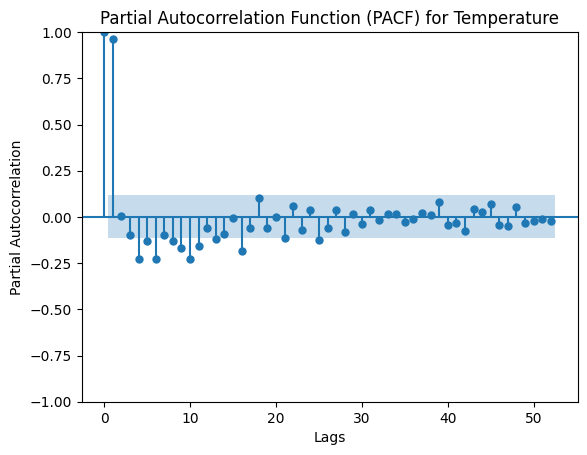

In [23]:
# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(df["temp"], lags=52, alpha=0.05)
plt.title('Autocorrelation Function (ACF) for Temperature')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(df["temp"], lags=52, alpha=0.05)
plt.title('Partial Autocorrelation Function (PACF) for Temperature')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

From PACF we can see that the first two lags are significant, while the rest is closer to 0, so it is insignificant.
 But note that ACF can be influenced by trends and seasonality, and we should pay more attention to the results obtained statistical tests like ADF and KPSS

In [24]:
df.to_csv("yerevan_weather.csv", index=False)    